### Gradient Descent

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import sympy as sp

In [58]:
# SYMPY parameters
x, y, z = sp.symbols('x y z')
variables = (x, y, z)

# VISUALIZATION PARAMETERS
X_RANGE = (-10, 10)
Y_RANGE = (-10, 10)
Z_FIXED = 0
GRID_SIZE = 100

# GRADIENT DESCENT PARAMETERS
INITIAL_POINT = [10, 10, 0]
LEARNING_RATE = 0.01
GRADIENT_CLIPPING = True
CLIPPING_VAL = 10.0
MAX_ITERATIONS = 1000

In [59]:
def mesh_intialize(f, x_range=X_RANGE, y_range=Y_RANGE, z_fixed=Z_FIXED, grid_size=GRID_SIZE):
    """ 
    Initializes the mesh grid for visualization

    INPUT ::
    f : sympy expression
    x_range : tuple ( min, max ) range for x-axis
    y_range : tuple ( min, max ) range for y-axis
    z_fixed : float value to fix z-axis for 2D contour plot
    grid_size : int number of points in the grid for both x and y axis

    OUTPUT ::
    fig : matplotlib figure object
    ax : matplotlib axes object
    dot : matplotlib line object for current position
    path : matplotlib line object for path taken by gradient descent
    """
    f_num = sp.lambdify(variables, f, 'numpy')

    list_x = np.linspace(x_range[0], x_range[1], grid_size)
    list_y = np.linspace(y_range[0], y_range[1], grid_size)
    X, Y = np.meshgrid(list_x, list_y)

    Z = np.zeros_like(X)
    Z = f_num(X, Y, z_fixed)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)

    dot, = ax.plot([], [], 'ro', markersize=8, label="Current Position")
    path, = ax.plot([], [], 'r-', alpha=0.5, label="Path")
    marks = ax.scatter([], [], c='blue', s=10, alpha=0.2)
        
    ax.legend()
    return fig, ax, dot, path, marks

In [60]:
def mesh_update(dot, path, marks, history):
    """ 
    Updates the visualization

    INPUT ::
    dot : matplotlib Line2D object representing the current position
    path : matplotlib Line2D object representing the path taken
    history : list of points representing the history of positions
    
    OUTPUT ::
    dot : updated Line2D object for current position
    path : updated Line2D object for path taken

    """
    h_array = np.array(history)

    dot.set_data([history[-1][0]], [history[-1][1]])
    path.set_data(h_array[:, 0], h_array[:, 1])
    marks.set_offsets(h_array[:, :2]) # Takes X and Y columns

    return dot, path, marks

In [61]:
def init_function(input_parameters, variables=variables):
    """
    Defines the functions f to be optimized.

    INPUT :: 
    input_parameters : List of lists with all coefficients
    variables        : Tuple of sympy symbols for the polynome

    OUTPUT ::
    f                : The function f as a sympy expression 

    """
    x, y, z = variables
    f = 0

    list_x, list_y, list_z = input_parameters
    for cpt in range(len(list_x)):
        f += list_x[cpt] * x ** cpt + list_y[cpt] * y ** cpt + list_z[cpt] * z ** cpt

    return f

In [62]:
def gradient(f, variables):
    """
    Computes the gradient vector of f with respect to the variables.

    INPUT ::
    f         : The function f as a sympy expression
    variables : Tuple of sympy symbols for the polynome

    OUTPUT ::
    gradient_vector : List of sympy expressions representing the gradient vector of f

    """
    gradient_vector = [sp.diff(f, var) for var in variables]

    return gradient_vector

In [65]:
def gradient_descent(f, variables, initial_point=INITIAL_POINT, learning_rate=LEARNING_RATE, gradient_clipping=GRADIENT_CLIPPING, clipping_val = CLIPPING_VAL, max_iterations=MAX_ITERATIONS):
    """ 
    Performs gradient descent optimization on the function f.

    INPUT ::
    f                 : The function f as a sympy expression
    variables         : Tuple of sympy symbols for the polynome
    initial_point     : List of values for starting point of the optimization
    learning_rate     : Step size for each iteration of gradient descent
    gradient_clipping : Boolean to indicate whether to apply gradient clipping
    clipping_val      : Value to clip the gradients if gradient_clipping is True
    max_iterations    : Maximum number of iterations for the optimization

    OUTPUT ::
    point             : Final point after performing gradient descent optimization
    
    """
    point = np.array(initial_point, dtype=np.float64)
    grad = gradient(f, variables)
    grad_func = sp.lambdify(variables, grad, 'numpy')
    fig, ax, dot, path, marks = mesh_intialize(f)
    history = [point.copy()]

    plt.show()

    for i in range(max_iterations):
        grad_eval = grad_func(*point)

        if gradient_clipping:
            grad_eval = np.clip(grad_eval, -clipping_val, clipping_val)

        point -= learning_rate * grad_eval

        history.append(point.copy())
        
        if i % 10 == 0:
            mesh_update(dot, path, marks, history)
            display.clear_output(wait=True)
            display.display(fig)

    return point

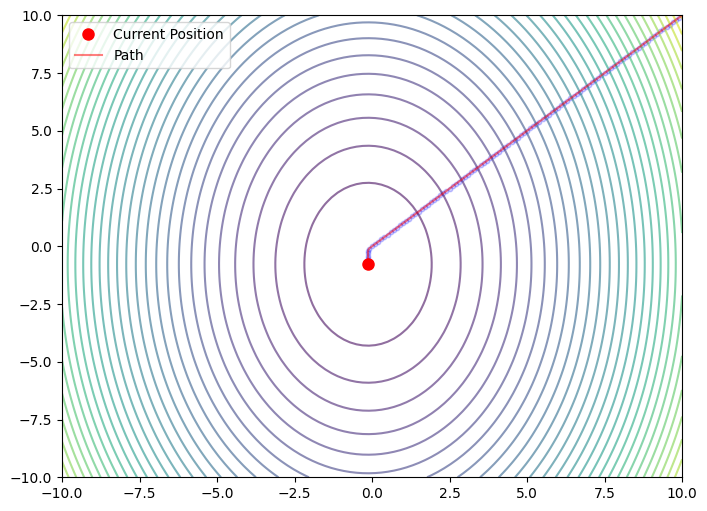

 Function f is 53*x**2 + 14*x + 18*y**2 + 28*y + 10*z**2 + 8*z + 38 ! 
 Gradient Vector of f is [106*x + 14, 36*y + 28, 20*z + 8] !
 Final point after gradient descent is [-0.13207547 -0.77777778 -0.4       ] !


In [67]:
f = init_function([[0, 14, 53], [4, 28, 18], [34, 8, 10]])
g = gradient(f, variables)
final_point = gradient_descent(f, variables)

print(f" Function f is {f} ! ")
print(f" Gradient Vector of f is {g} !")
print(f" Final point after gradient descent is {final_point} !")